In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
def load_direct_data(en, cont, alg, name):
    path = f"./Data/generation_ex/{en}/{cont}/{alg}/{name}"
    json_files = list(Path(path).glob("*.json"))
    print(f"Found {len(json_files)} files!")
    with open(json_files[0], "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

def extract_fitness_values(file_content):
    df = pd.DataFrame(file_content["fitness"]).reset_index(names="seed").melt(
        id_vars="seed", 
        var_name="ng", 
        value_name="population"
    )
    df["ng"] = df["ng"].astype(int)
    df["max_fit"] = df["population"].apply(lambda x: np.max(list(map(lambda y: y[0], x))))
    df["avg_fit"] = df["population"].apply(lambda x: np.mean(list(map(lambda y: y[0], x))))
    df["median_fit"] = df["population"].apply(lambda x: np.median(list(map(lambda y: y[0], x))))
    df["min_fit"] = df["population"].apply(lambda x: np.min(list(map(lambda y: y[0], x))))
    df["std_fit"] = df["population"].apply(lambda x: np.std(list(map(lambda y: y[0], x))))
    return df

In [18]:
file_content = load_direct_data("lunarlander", "novelty_limit", "lambda", "fourth_try")
df = extract_fitness_values(file_content)

Found 1 files!


In [19]:


df

,seed,ng,population,max_fit,avg_fit,median_fit,min_fit,std_fit
0,103,15,"[[[-460.90765895427944], [0.14946178197860718,...",-63.094953,-456.437344,-460.907685,-545.797372,4.841227e+01
1,102,15,"[[[-179.24551917207597], [-0.19326465129852294...",-179.245519,-203.485537,-179.245519,-279.057358,4.280026e+01
2,101,15,"[[[-420.0762934444785], [-0.015941886603832243...",26.256554,-417.794942,-420.076293,-539.341359,5.727271e+01
3,105,15,"[[[-213.22348006633706], [0.1748594284057617, ...",-213.223480,-312.831365,-213.223480,-471.466146,1.257031e+02
4,104,15,"[[[-408.676895516737], [0.010043144226074219, ...",-408.676896,-408.676896,-408.676896,-408.676896,1.136868e-13
5,103,35,"[[[-460.90765895427944], [0.14946178197860718,...",-460.907659,-460.907672,-460.907672,-460.907685,1.315834e-05
6,102,35,"[[[-179.24551917207597], [-0.19326465129852294...",-179.245519,-179.245519,-179.245519,-179.245519,2.842171e-14
7,101,35,"[[[-540.1852773455373], [-0.13699852228164672,...",-540.185277,-540.185277,-540.185277,-540.185277,2.273737e-13
8,105,35,"[[[-213.22348006633706], [0.1748594284057617, ...",-213.223480,-213.223480,-213.223480,-213.223480,2.842171e-14
9,104,35,"[[[-408.676895516737], [0.010043144226074219, ...",-408.676896,-408.676896,-408.676896,-408.676896,1.136868e-13


<Axes: xlabel='ng', ylabel='value'>

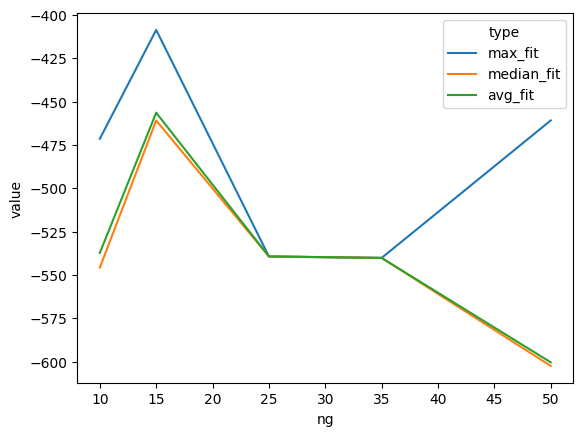

In [22]:
import seaborn as sns
df = df.sort_values("ng")
ploted_df = df[["ng", "seed", "max_fit", "median_fit", "avg_fit"]]
ploted_df = ploted_df.groupby("ng").min().reset_index()
if "seed" in ploted_df.columns:
    ploted_df = ploted_df.drop(columns="seed")
ploted_df = ploted_df.melt(
        id_vars="ng", 
        var_name="type", 
        value_name="value"
    )
sns.lineplot(data=ploted_df, x="ng", y="value", hue="type")